# 03 Grid Extension

In [5]:
import torch
from kan import KAN, create_dataset
import matplotlib.pyplot as plt

In [6]:
f = lambda x: torch.exp(torch.sin(torch.pi*x[:,[0]]) + x[:,[1]]**2)
dataset = create_dataset(f, n_var=2, train_num=1000, test_num=1000, ranges=[-1, 1])

## Train with a small grid (grid=3)

In [ ]:
model = KAN(width=[2, 1, 1], grid=3, k=3, seed=42)
results_g3 = model.fit(dataset, opt="LBFGS", steps=200, lr=1.0, lamb=0.001)
print(f"Grid 3 - final test RMSE: {results_g3['test_loss'][-1]:.6f}")

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.40e-02 | test_loss: 1.44e-02 | reg: 5.78e+00 | : 100%|█| 200/200 [00:21<00:00,  9.36

saving model version 0.1
Grid 3 - final test RMSE: 0.014370


## Extend the grid to higher resolutions

In [8]:
all_test_losses = list(results_g3["test_loss"])
refinement_points = []

for new_grid in [5, 10, 20, 50, 100, 200, 500, 1000]:
    model = model.refine(new_grid)
    refinement_points.append(len(all_test_losses))
    res = model.fit(dataset, opt="LBFGS", steps=200, lamb=0.001)
    all_test_losses.extend(res["test_loss"])
    print(f"Grid {new_grid:2d} - final test RMSE: {res['test_loss'][-1]:.6f}")

saving model version 0.2


| train_loss: 1.28e-02 | test_loss: 1.32e-02 | reg: 5.77e+00 | : 100%|█| 200/200 [00:07<00:00, 26.98


saving model version 0.3
Grid  5 - final test RMSE: 0.013241
saving model version 0.4


| train_loss: 1.25e-02 | test_loss: 1.30e-02 | reg: 5.78e+00 | : 100%|█| 200/200 [00:09<00:00, 21.17


saving model version 0.5
Grid 10 - final test RMSE: 0.012998
saving model version 0.6


...

saving model version 0.13
Grid 200 - final test RMSE: nan
saving model version 0.14


| train_loss: nan | test_loss: nan | reg: nan | : 100%|███████████| 200/200 [04:54<00:00,  1.47s/it]


saving model version 0.15
Grid 500 - final test RMSE: nan
saving model version 0.16


| train_loss: nan | test_loss: nan | reg: nan | : 100%|███████████| 200/200 [09:38<00:00,  2.89s/it]

saving model version 0.17
Grid 1000 - final test RMSE: nan


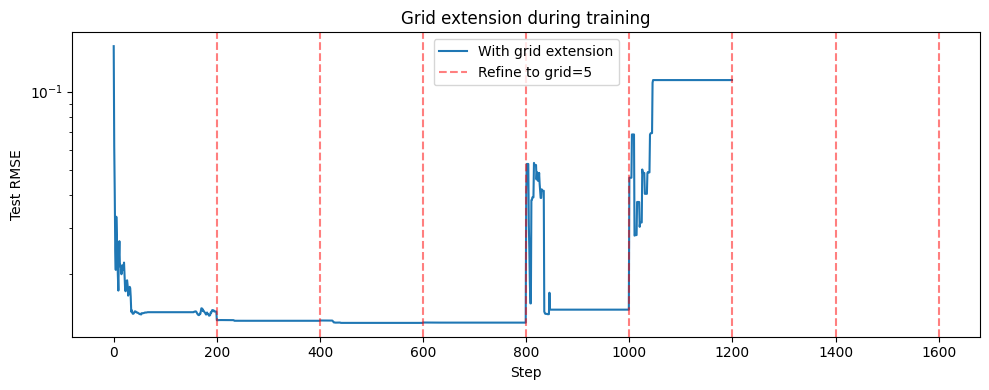

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(all_test_losses, label="With grid extension")
for i, rp in enumerate(refinement_points):
    ax.axvline(rp, color="red", linestyle="--", alpha=0.5,
               label=f"Refine to grid={[5,10,20][i]}" if i == 0 else None)
ax.set_xlabel("Step")
ax.set_ylabel("Test RMSE")
ax.set_yscale("log")
ax.legend()
ax.set_title("Grid extension during training")
plt.tight_layout()
plt.show()